In [3]:
import pandas as pd

customer = pd.read_csv('./E-Commerce dataset/olist_customers_dataset.csv')
orders = pd.read_csv('./E-Commerce dataset/olist_orders_dataset.csv')
payments = pd.read_csv('./E-Commerce dataset/olist_order_payments_dataset.csv')

df_merged =pd.merge(orders, customer , on="customer_id")
df_merged = pd.merge(df_merged, payments, on="order_id")

print(df_merged.columns)

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='str')


In [4]:
df_clean = df_merged[df_merged['order_status'] == 'delivered'].copy()

df_clean['order_purchase_timestamp'] = pd.to_datetime(df_clean['order_purchase_timestamp'])

cols_to_keep = ['customer_unique_id', 'order_id', 'order_purchase_timestamp', 'payment_value']
df_rfm_base = df_clean[cols_to_keep]

print(df_rfm_base.columns)

Index(['customer_unique_id', 'order_id', 'order_purchase_timestamp',
       'payment_value'],
      dtype='str')


In [5]:
import datetime as dt

reference_date = df_rfm_base['order_purchase_timestamp'].max() + dt.timedelta(days=1)

rfm = df_rfm_base.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (reference_date - x.max()).days,
    'order_id': 'nunique',
    'payment_value': 'sum'
}).reset_index()

rfm.rename(columns={
    'order_purchase_timestamp': 'Recency',
    'order_id': 'Frequency',
    'payment_value': 'Monetary'
}, inplace=True)

print(rfm.head())
print("\n-- Quick Statistics --")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe() )

                 customer_unique_id  Recency  Frequency  Monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19
2  0000f46a3911fa3c0805444483337064      537          1     86.22
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89

-- Quick Statistics --
            Recency     Frequency      Monetary
count  93357.000000  93357.000000  93357.000000
mean     237.936673      1.033420    165.198772
std      152.584315      0.209099    226.314579
min        1.000000      1.000000      9.590000
25%      114.000000      1.000000     63.060000
50%      219.000000      1.000000    107.780000
75%      346.000000      1.000000    182.560000
max      695.000000     15.000000  13664.080000


In [6]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1])

rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5])

def score_frequency(x):
    if x <= 1:
        return 1
    elif x == 2:
        return 2
    elif x == 3:
        return 3
    else:
        return 4

rfm['F_Score'] = rfm['Frequency'].apply(score_frequency)

rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

rfm['RFM_Score'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)
print(rfm[['customer_unique_id', 'Recency', 'Frequency', 'Monetary', 'RFM_Segment', 'RFM_Score']].head())

                 customer_unique_id  Recency  Frequency  Monetary RFM_Segment  \
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90         414   
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19         411   
2  0000f46a3911fa3c0805444483337064      537          1     86.22         112   
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62         211   
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89         214   

   RFM_Score  
0          9  
1          6  
2          4  
3          4  
4          7  


In [7]:
# 1. Create a function to assign segments based on the score
def assign_segment(score):
    if score >= 11:
        return 'Champions'
    elif score >= 9:
        return 'Loyal Customers'
    elif score >= 7:
        return 'Potential Loyalists'
    elif score >= 5:
        return 'At Risk'
    else:
        return 'Lost'

# 2. Apply this function to create a new column
rfm['Customer_Profile'] = rfm['RFM_Score'].apply(assign_segment)

# 3. Let's see how many customers fall into each group!
print("--- Number of Customers per Profile ---")
print(rfm['Customer_Profile'].value_counts())

# 4. Let's look at the average behavior of each group
print("\n--- Average Behavior per Profile ---")
print(rfm.groupby('Customer_Profile')[['Recency', 'Frequency', 'Monetary']].mean().round(1).sort_values('Monetary', ascending=False))

--- Number of Customers per Profile ---
Customer_Profile
Potential Loyalists    32955
At Risk                25727
Loyal Customers        18997
Lost                   11337
Champions               4341
Name: count, dtype: int64

--- Average Behavior per Profile ---
                     Recency  Frequency  Monetary
Customer_Profile                                 
Champions               55.3        1.3     440.3
Loyal Customers        119.8        1.1     256.6
Potential Loyalists    213.3        1.0     178.9
At Risk                305.5        1.0      84.2
Lost                   424.2        1.0      50.6


C:\Users\ramak\AppData\Local\Temp\ipykernel_31548\3260916419.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Customer_Profile', data=segment_counts, palette='viridis', ax=ax)


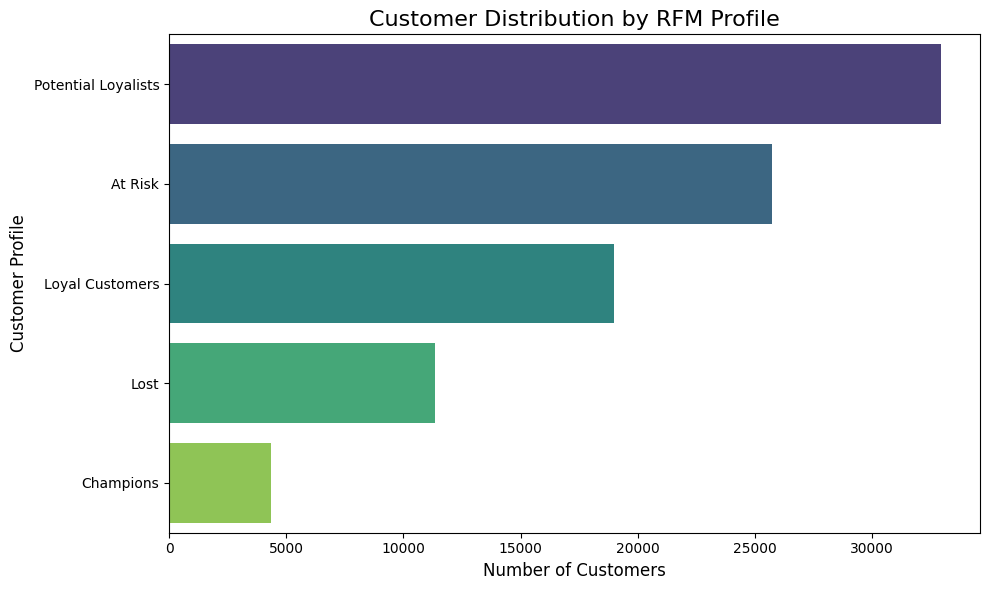

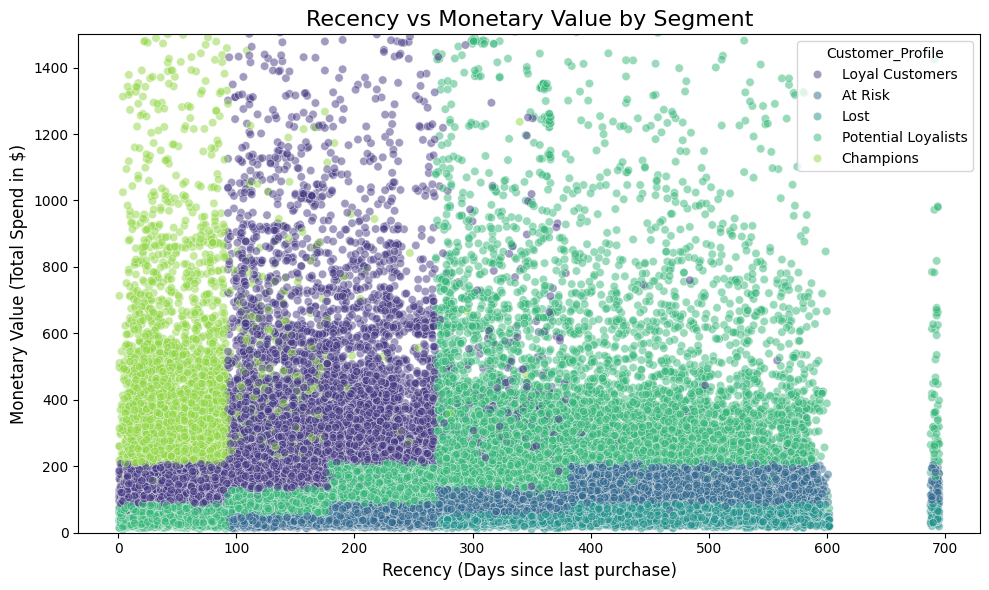

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Chart 1: Bar Chart of Customer Segments
# ==========================================

# 1. Count the number of customers in each segment
segment_counts = rfm['Customer_Profile'].value_counts().reset_index()
segment_counts.columns = ['Customer_Profile', 'Count']

# 2. Create the Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='Count', y='Customer_Profile', data=segment_counts, palette='viridis', ax=ax)

# 3. Add titles and labels to make it readable
ax.set_title('Customer Distribution by RFM Profile', fontsize=16)
ax.set_xlabel('Number of Customers', fontsize=12)
ax.set_ylabel('Customer Profile', fontsize=12)
plt.tight_layout()
plt.show() # In your notebook, use show() to display it!

# ==========================================
# Chart 2: Scatter Plot (Recency vs Monetary)
# ==========================================

fig2, ax2 = plt.subplots(figsize=(10, 6))

# We plot Recency on the X-axis and Monetary on the Y-axis. 
# "hue" colors the dots based on their segment!
sns.scatterplot(x='Recency', y='Monetary', hue='Customer_Profile', data=rfm, palette='viridis', alpha=0.5, ax=ax2)

ax2.set_title('Recency vs Monetary Value by Segment', fontsize=16)
ax2.set_xlabel('Recency (Days since last purchase)', fontsize=12)
ax2.set_ylabel('Monetary Value (Total Spend in $)', fontsize=12)

# We cap the Y-axis at $1500 to zoom in, because a few extreme outliers (spending $13,000+) can squish the whole chart
ax2.set_ylim(0, 1500) 

plt.tight_layout()
plt.show()